In [10]:
# Requirements
# transformers==4.35.0
# datasets
# torch
# matplotlib

# Experiment 2: Boundary Divergence — Five Seeds, All Pairwise Combinations

This notebook trains five GPT-2 sentiment classifiers on SST-2 using different
random seeds and computes boundary divergence across all 10 pairwise model
combinations. Models are evaluated on three OOD datasets: IMDB, Amazon Polarity,
and TweetEval.

**Paper:** Boundary Divergence: A Geometric Diagnostic of Cross-Model Disagreement
**Author:** Elizabeth J. Taylor
**Corresponds to:** Section 4.1, 5.1, 5.2, 5.3 of the paper

## Key results
- 12/30 dataset-pair combinations significant
- Mean asymmetry ratio among significant pairs: 2.58x
- Effect is not universal across all seed pairs

## Runtime
Approximately 60–90 minutes on a single GPU T4.

In [11]:
# install and imports
!pip install transformers datasets scipy scikit-learn -q

import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import defaultdict

# tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# load and prepare training data
print("Loading datasets...")
sst2_train = load_dataset("sst2", split="train")
sst2_val = load_dataset("sst2", split="validation")

def tokenize(batch):
    return tokenizer(batch["sentence"], padding="max_length", truncation=True, max_length=64)

train_tokenized = sst2_train.map(tokenize, batched=True)
val_tokenized = sst2_val.map(tokenize, batched=True)
train_tokenized = train_tokenized.rename_column("label", "labels")
val_tokenized = val_tokenized.rename_column("label", "labels")
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# load OOD datasets
imdb = load_dataset("imdb", split="test[:500]")
amazon = load_dataset("amazon_polarity", split="test[:500]")
tweets = load_dataset("tweet_eval", "sentiment", split="test[:500]")

imdb_sentences = [x["text"][:300] for x in imdb]
amazon_sentences = [x["content"][:300] for x in amazon]
tweet_sentences = [x["text"][:300] for x in tweets]
imdb_labels = [x["label"] for x in imdb]
amazon_labels = [x["label"] for x in amazon]
tweet_labels = [x["label"] for x in tweets]

print("Data ready.")

# train function
def train_model(seed):
    torch.manual_seed(seed)
    model = GPT2ForSequenceClassification.from_pretrained(
        "gpt2", num_labels=2, ignore_mismatched_sizes=True)
    model.config.pad_token_id = tokenizer.eos_token_id

    # Note: output path is Kaggle-specific. If running locally, 
    # change to a local path e.g. f"./outputs/model_{seed}"
    args = TrainingArguments(
        output_dir=f"/kaggle/working/model_{seed}",
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        seed=seed,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=200,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
    )
    
    trainer.train()
    results = trainer.evaluate()
    print(f"Seed {seed} eval loss: {results['eval_loss']:.4f}")
    return model

# train 5 models
seeds = [42, 99, 123, 456, 789]
trained_models = []

for seed in seeds:
    print(f"\nTraining model seed={seed}...")
    m = train_model(seed)
    trained_models.append(m)

print(f"\nAll {len(trained_models)} models trained.")

Loading datasets...
Data ready.

Training model seed=42...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.471161,0.468583
2,0.361740,0.527954


Seed 42 eval loss: 0.5280

Training model seed=99...


...

Seed 456 eval loss: 0.5132

Training model seed=789...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.463043,0.501161
2,0.379679,0.508843


Seed 789 eval loss: 0.5088

All 5 models trained.


In [12]:
device = next(trained_models[0].parameters()).device
print(f"Device: {device}")

def get_predictions(model, encoded):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(len(encoded['input_ids'])):
            input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
            attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred = outputs.logits.argmax(dim=-1).item()
            predictions.append(pred)
    
    return np.array(predictions)

def get_boundary_scores(model, encoded):
    model.eval()
    scores = []
    
    for i in range(len(encoded['input_ids'])):
        input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
        attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
        
        inputs_embeds = model.transformer.wte(input_ids).detach().requires_grad_(True).to(device)
        
        outputs = model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        margin = logits[0, 1] - logits[0, 0]
        margin.backward()
        
        score = inputs_embeds.grad.norm().item()
        scores.append(score)
    
    return np.array(scores)

def bootstrap_asymmetry(disagreement, divergence, n_bootstrap=200):
    ratios = []
    n = len(disagreement)
    
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        dis = disagreement[idx]
        div = divergence[idx]
        
        median_div = np.median(div)
        high = div > median_div
        low = div <= median_div
        
        p_high = dis[high].mean()
        p_low = dis[low].mean()
        ratio = p_high / (p_low + 1e-10)
        ratios.append(ratio)
    
    ratios = np.array(ratios)
    return np.mean(ratios), np.percentile(ratios, 2.5), np.percentile(ratios, 97.5)

# load OOD datasets
imdb = load_dataset("imdb", split="test[:500]")
amazon = load_dataset("amazon_polarity", split="test[:500]")
tweets = load_dataset("tweet_eval", "sentiment", split="test[:500]")

imdb_sentences = [x["text"][:300] for x in imdb]
amazon_sentences = [x["content"][:300] for x in amazon]
tweet_sentences = [x["text"][:300] for x in tweets]
imdb_labels = [x["label"] for x in imdb]
amazon_labels = [x["label"] for x in amazon]
tweet_labels = [x["label"] for x in tweets]

print("Ready.")

Device: cuda:0
Ready.


In [13]:
from itertools import combinations

all_results = []

for i, j in combinations(range(len(trained_models)), 2):
    model_i = trained_models[i]
    model_j = trained_models[j]
    pair_name = f"seed{seeds[i]} vs seed{seeds[j]}"
    print(f"\nPair: {pair_name}")
    
    enc_imdb = tokenizer(imdb_sentences, padding=True, truncation=True, max_length=64, return_tensors="pt")
    enc_amazon = tokenizer(amazon_sentences, padding=True, truncation=True, max_length=64, return_tensors="pt")
    enc_tweets = tokenizer(tweet_sentences, padding=True, truncation=True, max_length=64, return_tensors="pt")
    
    for enc, name in [
        (enc_imdb, "IMDB"),
        (enc_amazon, "Amazon"),
        (enc_tweets, "Tweets")
    ]:
        try:
            preds_i = get_predictions(model_i, enc)
            preds_j = get_predictions(model_j, enc)
            disagreement = (preds_i != preds_j).astype(int)
            
            scores_i = get_boundary_scores(model_i, enc)
            scores_j = get_boundary_scores(model_j, enc)
            divergence = np.abs(scores_i - scores_j)
            
            median_div = np.median(divergence)
            high_div = divergence > median_div
            low_div = divergence <= median_div
            
            p_high = disagreement[high_div].mean()
            p_low = disagreement[low_div].mean()
            ratio = p_high / (p_low + 1e-10)
            
            mean, ci_low, ci_high = bootstrap_asymmetry(disagreement, divergence)
            
            all_results.append({
                'pair': pair_name,
                'dataset': name,
                'ratio': ratio,
                'ci_low': ci_low,
                'ci_high': ci_high,
                'significant': ci_low > 1.0
            })
            
            print(f"  {name}: {ratio:.2f}x (CI: {ci_low:.2f}-{ci_high:.2f}) {'YES' if ci_low > 1.0 else 'NO'}")
        
        except Exception as e:
            print(f"  {name}: ERROR - {e}")

print(f"\nDone. Total results: {len(all_results)}")


Pair: seed42 vs seed99


GPT2ForSequenceClassification will not detect padding tokens in `inputs_embeds`. Results may be unexpected if using padding tokens in conjunction with `inputs_embeds.`


  IMDB: 2.50x (CI: 1.61-4.25) YES
  Amazon: 2.31x (CI: 1.46-3.35) YES
  Tweets: 2.00x (CI: 1.30-2.85) YES

Pair: seed42 vs seed123
  IMDB: 0.94x (CI: 0.86-1.04) NO
  Amazon: 0.72x (CI: 0.67-0.80) NO
  Tweets: 0.84x (CI: 0.79-0.93) NO

Pair: seed42 vs seed456
  IMDB: 3.73x (CI: 2.13-9.82) YES
  Amazon: 5.08x (CI: 2.84-9.01) YES
  Tweets: 5.20x (CI: 3.14-9.56) YES

Pair: seed42 vs seed789
  IMDB: 1.02x (CI: 0.89-1.14) NO
  Amazon: 0.84x (CI: 0.74-0.96) NO
  Tweets: 0.96x (CI: 0.90-1.04) NO

Pair: seed99 vs seed123
  IMDB: 0.79x (CI: 0.69-0.89) NO
  Amazon: 0.91x (CI: 0.78-1.05) NO
  Tweets: 1.34x (CI: 1.17-1.59) YES

Pair: seed99 vs seed456
  IMDB: 2.00x (CI: 1.06-3.25) YES
  Amazon: 1.65x (CI: 0.95-3.45) NO
  Tweets: 1.64x (CI: 0.96-3.43) NO

Pair: seed99 vs seed789
  IMDB: 0.79x (CI: 0.67-0.91) NO
  Amazon: 0.45x (CI: 0.35-0.57) NO
  Tweets: 0.58x (CI: 0.49-0.68) NO

Pair: seed123 vs seed456
  IMDB: 0.75x (CI: 0.66-0.83) NO
  Amazon: 0.97x (CI: 0.85-1.12) NO
  Tweets: 1.35x (CI: 1.18-1

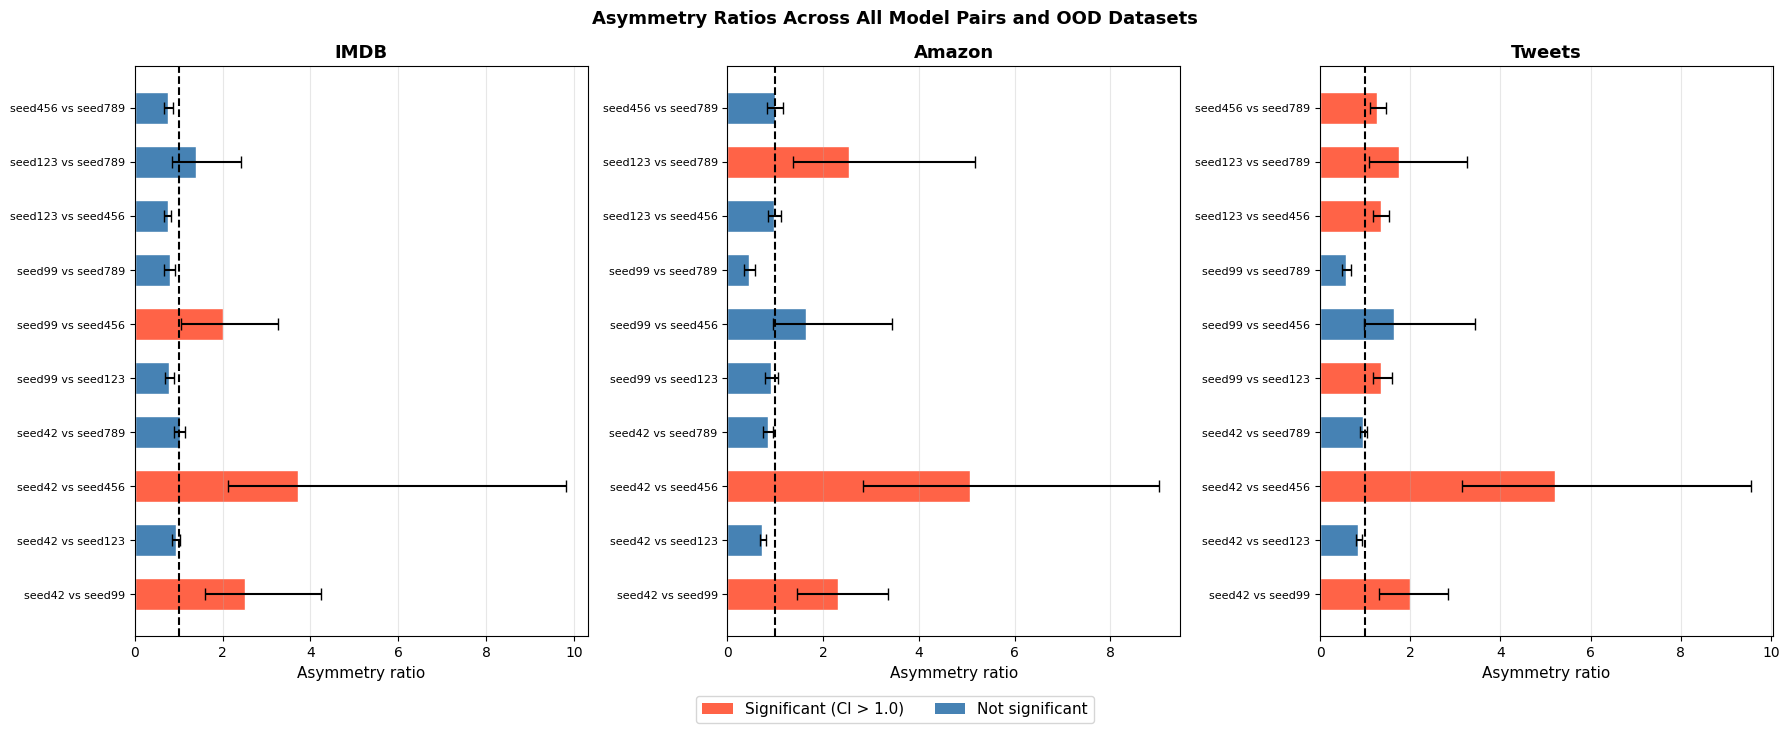

Total dataset-pair combinations: 30
Significant: 12/30 (40%)

Among significant results:
  Mean ratio: 2.59x
  Range: 1.26x - 5.20x

Pairs with ALL THREE datasets significant:
  seed42 vs seed99: 2.27x average
  seed42 vs seed456: 4.67x average

Pairs with NO significant results:
  seed99 vs seed789
  seed42 vs seed789
  seed42 vs seed123


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
datasets = ['IMDB', 'Amazon', 'Tweets']

for ax, dataset in zip(axes, datasets):
    dataset_results = [r for r in all_results if r['dataset'] == dataset]
    pair_labels = [r['pair'] for r in dataset_results]
    ratios = [r['ratio'] for r in dataset_results]
    ci_lows = [r['ratio'] - r['ci_low'] for r in dataset_results]
    ci_highs = [r['ci_high'] - r['ratio'] for r in dataset_results]
    significant = [r['significant'] for r in dataset_results]
    colors = ['tomato' if s else 'steelblue' for s in significant]
    y_pos = np.arange(len(pair_labels))
    ax.barh(y_pos, ratios, color=colors, edgecolor='white', height=0.6)
    ax.errorbar(ratios, y_pos, xerr=[ci_lows, ci_highs],
                fmt='none', color='black', capsize=4, linewidth=1.5)
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pair_labels, fontsize=8)
    ax.set_xlabel("Asymmetry ratio", fontsize=11)
    ax.set_title(f"{dataset}", fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

legend_elements = [
    Patch(facecolor='tomato', label='Significant (CI > 1.0)'),
    Patch(facecolor='steelblue', label='Not significant')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Asymmetry Ratios Across All Model Pairs and OOD Datasets",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figure_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

sig_results = [r for r in all_results if r['significant']]
nonsig_results = [r for r in all_results if not r['significant']]
pairs = list(set([r['pair'] for r in all_results]))

print(f"Total dataset-pair combinations: {len(all_results)}")
print(f"Significant: {len(sig_results)}/{len(all_results)} ({len(sig_results)/len(all_results)*100:.0f}%)")
print(f"\nAmong significant results:")
print(f"  Mean ratio: {np.mean([r['ratio'] for r in sig_results]):.2f}x")
print(f"  Range: {min([r['ratio'] for r in sig_results]):.2f}x - {max([r['ratio'] for r in sig_results]):.2f}x")
print(f"\nPairs with ALL THREE datasets significant:")
for pair in pairs:
    pair_results = [r for r in all_results if r['pair'] == pair]
    if all(r['significant'] for r in pair_results):
        ratios = [r['ratio'] for r in pair_results]
        print(f"  {pair}: {np.mean(ratios):.2f}x average")

print(f"\nPairs with NO significant results:")
for pair in pairs:
    pair_results = [r for r in all_results if r['pair'] == pair]
    if not any(r['significant'] for r in pair_results):
        print(f"  {pair}")

In [15]:
def test_boundary_correctness(model_A, model_B, sentences, labels, dataset_name):
    print(f"\nTesting {dataset_name}...")
    
    enc = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )
    
    # get predictions
    preds_A = get_predictions(model_A, enc)
    preds_B = get_predictions(model_B, enc)
    true_labels = np.array(labels[:len(preds_A)])
    
    # get boundary scores
    scores_A = get_boundary_scores(model_A, enc)
    scores_B = get_boundary_scores(model_B, enc)
    
    # find where models disagree
    disagreement_idx = np.where(preds_A != preds_B)[0]
    
    if len(disagreement_idx) == 0:
        print(f"  No disagreements found.")
        return None
    
    print(f"  Disagreements: {len(disagreement_idx)}")
    
    # for each disagreement, check which model was correct
    # and whether it had the lower boundary score
    lower_score_correct = 0
    higher_score_correct = 0
    neither_correct = 0
    
    for idx in disagreement_idx:
        score_a = scores_A[idx]
        score_b = scores_B[idx]
        pred_a = preds_A[idx]
        pred_b = preds_B[idx]
        true = true_labels[idx]
        
        a_correct = (pred_a == true)
        b_correct = (pred_b == true)
        a_lower = (score_a < score_b)
        
        if a_correct and a_lower:
            lower_score_correct += 1
        elif b_correct and not a_lower:
            lower_score_correct += 1
        elif a_correct and not a_lower:
            higher_score_correct += 1
        elif b_correct and a_lower:
            higher_score_correct += 1
        else:
            neither_correct += 1
    
    total = len(disagreement_idx)
    p_lower_correct = lower_score_correct / (total - neither_correct + 1e-10)
    
    print(f"  Lower boundary score correct: {lower_score_correct}/{total-neither_correct} ({p_lower_correct*100:.1f}%)")
    print(f"  Higher boundary score correct: {higher_score_correct}/{total-neither_correct} ({(1-p_lower_correct)*100:.1f}%)")
    print(f"  Neither correct: {neither_correct}/{total}")
    print(f"  Prediction: lower score should be correct > 50% of the time")
    
    return {
        'dataset': dataset_name,
        'disagreements': total,
        'p_lower_correct': p_lower_correct,
        'lower_correct': lower_score_correct,
        'higher_correct': higher_score_correct,
        'neither': neither_correct
    }

# run on the two strongest pairs
print("Testing whether lower boundary score predicts correctness")
print("=" * 60)
print("\nUsing seed42 vs seed456 (strongest pair, 4.67x average ratio)")

correctness_results = []

for dataset, sents, labs in [
    ("IMDB", imdb_sentences, imdb_labels),
    ("Amazon", amazon_sentences, amazon_labels),
    ("Tweets", tweet_sentences, tweet_labels)
]:
    r = test_boundary_correctness(
        trained_models[0],  # seed42
        trained_models[3],  # seed456
        sents, labs, dataset
    )
    if r:
        correctness_results.append(r)

print("\nDone.")

Testing whether lower boundary score predicts correctness

Using seed42 vs seed456 (strongest pair, 4.67x average ratio)

Testing IMDB...
  Disagreements: 52
  Lower boundary score correct: 8/52 (15.4%)
  Higher boundary score correct: 44/52 (84.6%)
  Neither correct: 0/52
  Prediction: lower score should be correct > 50% of the time

Testing Amazon...
  Disagreements: 79
  Lower boundary score correct: 67/79 (84.8%)
  Higher boundary score correct: 12/79 (15.2%)
  Neither correct: 0/79
  Prediction: lower score should be correct > 50% of the time

Testing Tweets...
  Disagreements: 93
  Lower boundary score correct: 40/50 (80.0%)
  Higher boundary score correct: 10/50 (20.0%)
  Neither correct: 43/93
  Prediction: lower score should be correct > 50% of the time

Done.


In [16]:
# compare average boundary scores on correct vs incorrect predictions
# for IMDB specifically

enc_imdb = tokenizer(
    imdb_sentences,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

preds_A = get_predictions(trained_models[0], enc_imdb)
preds_B = get_predictions(trained_models[3], enc_imdb)
true_labels = np.array(imdb_labels[:len(preds_A)])

scores_A = get_boundary_scores(trained_models[0], enc_imdb)
scores_B = get_boundary_scores(trained_models[3], enc_imdb)

# for disagreement cases only
disagreement_idx = np.where(preds_A != preds_B)[0]

a_correct_scores = []
a_wrong_scores = []

for idx in disagreement_idx:
    if preds_A[idx] == true_labels[idx]:
        a_correct_scores.append(scores_A[idx])
    else:
        a_wrong_scores.append(scores_A[idx])

print("IMDB diagnostic — Model A boundary scores on disagreement cases:")
print(f"  When Model A is CORRECT: mean score = {np.mean(a_correct_scores):.3f}")
print(f"  When Model A is WRONG:   mean score = {np.mean(a_wrong_scores):.3f}")
print()
print(f"  Correct predictions have {'HIGHER' if np.mean(a_correct_scores) > np.mean(a_wrong_scores) else 'LOWER'} boundary scores on IMDB")
print()

# look at the actual sentences where imdb reverses
print("Sample IMDB sentences where HIGHER boundary score model is correct:")
count = 0
for idx in disagreement_idx:
    score_a = scores_A[idx]
    score_b = scores_B[idx]
    if score_a > score_b and preds_A[idx] == true_labels[idx]:
        print(f"  score_A={score_a:.2f} score_B={score_b:.2f} | '{imdb_sentences[idx][:100]}'")
        count += 1
    if count >= 5:
        break

IMDB diagnostic — Model A boundary scores on disagreement cases:
  When Model A is CORRECT: mean score = 10.151
  When Model A is WRONG:   mean score = 15.659

  Correct predictions have LOWER boundary scores on IMDB

Sample IMDB sentences where HIGHER boundary score model is correct:
  score_A=5.58 score_B=4.70 | 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-a'
  score_A=5.38 score_B=3.46 | 'I had high hopes for this one until they changed the name to 'The Shepherd : Border Patrol, the lame'
  score_A=3.46 score_B=3.11 | 'I first watched this movie back in the mid/late 80's, when I was a kid. We couldn't even get all the'
  score_A=4.41 score_B=2.97 | 'Every movie I have PPV'd because Leonard Maltin praised it to the skies has blown chunks! Every sing'
  score_A=32.80 score_B=18.40 | 'Beware, My Lovely (1952) Dir: Harry Horner <br /><br />Production: The Filmmakers/RKO Radio Pictures'


In [17]:
from scipy.stats import pointbiserialr
import torch.nn.functional as F

def get_confidence_and_entropy(model, encoded):
    model.eval()
    confidences = []
    entropies = []
    
    with torch.no_grad():
        for i in range(len(encoded['input_ids'])):
            input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
            attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = F.softmax(outputs.logits, dim=-1)[0]
            
            confidence = probs.max().item()
            entropy = -(probs * probs.log()).sum().item()
            
            confidences.append(confidence)
            entropies.append(entropy)
    
    return np.array(confidences), np.array(entropies)

print("Comparing boundary divergence vs confidence vs entropy")
print("as predictors of model disagreement")
print("=" * 60)

for dataset, sents, labs in [
    ("IMDB", imdb_sentences, imdb_labels),
    ("Amazon", amazon_sentences, amazon_labels),
    ("Tweets", tweet_sentences, tweet_labels)
]:
    print(f"\n{dataset}:")
    
    enc = tokenizer(sents, padding=True, truncation=True,
                    max_length=64, return_tensors="pt")
    
    # get disagreement labels
    preds_A = get_predictions(trained_models[0], enc)
    preds_B = get_predictions(trained_models[3], enc)
    disagreement = (preds_A != preds_B).astype(int)
    
    # get boundary divergence
    scores_A = get_boundary_scores(trained_models[0], enc)
    scores_B = get_boundary_scores(trained_models[3], enc)
    divergence = np.abs(scores_A - scores_B)
    
    # get confidence and entropy for both models
    conf_A, ent_A = get_confidence_and_entropy(trained_models[0], enc)
    conf_B, ent_B = get_confidence_and_entropy(trained_models[3], enc)
    
    # average across both models
    avg_confidence = (conf_A + conf_B) / 2
    avg_entropy = (ent_A + ent_B) / 2
    conf_divergence = np.abs(conf_A - conf_B)
    
    # correlate each predictor with disagreement
    r_div, p_div = pointbiserialr(disagreement, divergence)
    r_conf, p_conf = pointbiserialr(disagreement, 1 - avg_confidence)
    r_ent, p_ent = pointbiserialr(disagreement, avg_entropy)
    r_confdiv, p_confdiv = pointbiserialr(disagreement, conf_divergence)
    
    print(f"  Boundary divergence:     r={r_div:.3f} p={p_div:.4f}")
    print(f"  1 - Confidence:          r={r_conf:.3f} p={p_conf:.4f}")
    print(f"  Entropy:                 r={r_ent:.3f} p={p_ent:.4f}")
    print(f"  Confidence divergence:   r={r_confdiv:.3f} p={p_confdiv:.4f}")
    print(f"  --- boundary divergence adds unique signal: {'YES' if r_div > r_confdiv else 'CHECK'}")

print("\nDone.")

Comparing boundary divergence vs confidence vs entropy
as predictors of model disagreement

IMDB:
  Boundary divergence:     r=0.254 p=0.0000
  1 - Confidence:          r=0.554 p=0.0000
  Entropy:                 r=0.532 p=0.0000
  Confidence divergence:   r=0.294 p=0.0000
  --- boundary divergence adds unique signal: CHECK

Amazon:
  Boundary divergence:     r=0.132 p=0.0030
  1 - Confidence:          r=0.543 p=0.0000
  Entropy:                 r=0.549 p=0.0000
  Confidence divergence:   r=0.288 p=0.0000
  --- boundary divergence adds unique signal: CHECK

Tweets:
  Boundary divergence:     r=0.344 p=0.0000
  1 - Confidence:          r=0.560 p=0.0000
  Entropy:                 r=0.579 p=0.0000
  Confidence divergence:   r=0.107 p=0.0164
  --- boundary divergence adds unique signal: YES

Done.


In [18]:
from scipy.stats import pearsonr

print("How correlated is boundary divergence with confidence metrics?")
print("If r is low, they are measuring different things.")
print("=" * 60)

for dataset, sents in [
    ("IMDB", imdb_sentences),
    ("Amazon", amazon_sentences),
    ("Tweets", tweet_sentences)
]:
    print(f"\n{dataset}:")
    
    enc = tokenizer(sents, padding=True, truncation=True,
                    max_length=64, return_tensors="pt")
    
    scores_A = get_boundary_scores(trained_models[0], enc)
    scores_B = get_boundary_scores(trained_models[3], enc)
    divergence = np.abs(scores_A - scores_B)
    
    conf_A, ent_A = get_confidence_and_entropy(trained_models[0], enc)
    conf_B, ent_B = get_confidence_and_entropy(trained_models[3], enc)
    avg_confidence = (conf_A + conf_B) / 2
    avg_entropy = (ent_A + ent_B) / 2
    
    r_div_conf, _ = pearsonr(divergence, 1 - avg_confidence)
    r_div_ent, _ = pearsonr(divergence, avg_entropy)
    
    print(f"  Boundary divergence vs 1-confidence: r={r_div_conf:.3f}")
    print(f"  Boundary divergence vs entropy:      r={r_div_ent:.3f}")
    print(f"  --- these metrics are {'HIGHLY correlated' if abs(r_div_conf) > 0.7 else 'PARTIALLY independent' if abs(r_div_conf) > 0.4 else 'LARGELY INDEPENDENT'}")

How correlated is boundary divergence with confidence metrics?
If r is low, they are measuring different things.

IMDB:
  Boundary divergence vs 1-confidence: r=0.162
  Boundary divergence vs entropy:      r=0.168
  --- these metrics are LARGELY INDEPENDENT

Amazon:
  Boundary divergence vs 1-confidence: r=0.268
  Boundary divergence vs entropy:      r=0.312
  --- these metrics are LARGELY INDEPENDENT

Tweets:
  Boundary divergence vs 1-confidence: r=0.490
  Boundary divergence vs entropy:      r=0.511
  --- these metrics are PARTIALLY independent


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("Combined predictor test")
print("Does boundary divergence add signal BEYOND confidence alone?")
print("=" * 60)

for dataset, sents, labs in [
    ("IMDB", imdb_sentences, imdb_labels),
    ("Amazon", amazon_sentences, amazon_labels),
    ("Tweets", tweet_sentences, tweet_labels)
]:
    print(f"\n{dataset}:")
    
    enc = tokenizer(sents, padding=True, truncation=True,
                    max_length=64, return_tensors="pt")
    
    preds_A = get_predictions(trained_models[0], enc)
    preds_B = get_predictions(trained_models[3], enc)
    disagreement = (preds_A != preds_B).astype(int)
    
    scores_A = get_boundary_scores(trained_models[0], enc)
    scores_B = get_boundary_scores(trained_models[3], enc)
    divergence = np.abs(scores_A - scores_B)
    
    conf_A, ent_A = get_confidence_and_entropy(trained_models[0], enc)
    conf_B, ent_B = get_confidence_and_entropy(trained_models[3], enc)
    avg_entropy = (ent_A + ent_B) / 2

    scaler = StandardScaler()
    
    # predictor 1: entropy alone
    X_entropy = scaler.fit_transform(avg_entropy.reshape(-1, 1))
    auc_entropy = roc_auc_score(disagreement, X_entropy)
    
    # predictor 2: boundary divergence alone
    X_div = scaler.fit_transform(divergence.reshape(-1, 1))
    auc_div = roc_auc_score(disagreement, X_div)
    
    # predictor 3: combined
    X_combined = scaler.fit_transform(
        np.stack([divergence, avg_entropy], axis=1))
    lr = LogisticRegression()
    lr.fit(X_combined, disagreement)
    auc_combined = roc_auc_score(disagreement, lr.predict_proba(X_combined)[:, 1])
    
    print(f"  AUC entropy alone:           {auc_entropy:.3f}")
    print(f"  AUC boundary divergence:     {auc_div:.3f}")
    print(f"  AUC combined:                {auc_combined:.3f}")
    print(f"  Boundary divergence adds:    {(auc_combined - auc_entropy)*100:.1f}% AUC improvement")

Combined predictor test
Does boundary divergence add signal BEYOND confidence alone?

IMDB:
  AUC entropy alone:           0.924
  AUC boundary divergence:     0.727
  AUC combined:                0.934
  Boundary divergence adds:    1.0% AUC improvement

Amazon:
  AUC entropy alone:           0.909
  AUC boundary divergence:     0.702
  AUC combined:                0.909
  Boundary divergence adds:    -0.0% AUC improvement

Tweets:
  AUC entropy alone:           0.918
  AUC boundary divergence:     0.777
  AUC combined:                0.919
  Boundary divergence adds:    0.1% AUC improvement
